# Task 1: Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import norm

df = pd.read_csv('spiff_data2.csv', index_col=0)
cols = ['gurkor','guitars','slingshots','stocks','sugar','water','tranquillity']

## 1. Data overview

The dataset has 5456 rows and 7 price series spanning days 1–5456 (~21.6 years at 252 trading days/year).
Each series has a **50-point internal gap** (at different locations) and a shared **200-point trailing gap** starting at day 5257.

| Series | Internal gap (days) | Trailing gap |
|---|---|---|
| gurkor | 199–248 | 5257–5456 |
| guitars | 399–448 | 5257–5456 |
| slingshots | 599–648 | 5257–5456 |
| stocks | 799–848 | 5257–5456 |
| sugar | 999–1048 | 5257–5456 |
| water | 1199–1248 | 5257–5456 |
| tranquillity | 1399–1448 | 5257–5456 |

Total NaN per series: 250 (= 50 internal + 200 trailing).

**Data artifact:** 5 rows (36, 1194, 2836, 3430, 4118) have all 7 series simultaneously set to exactly 1000 — clearly data entry errors. We replace these with NaN.

## 2. Raw price series
Plotting before any cleaning to see the spikes.

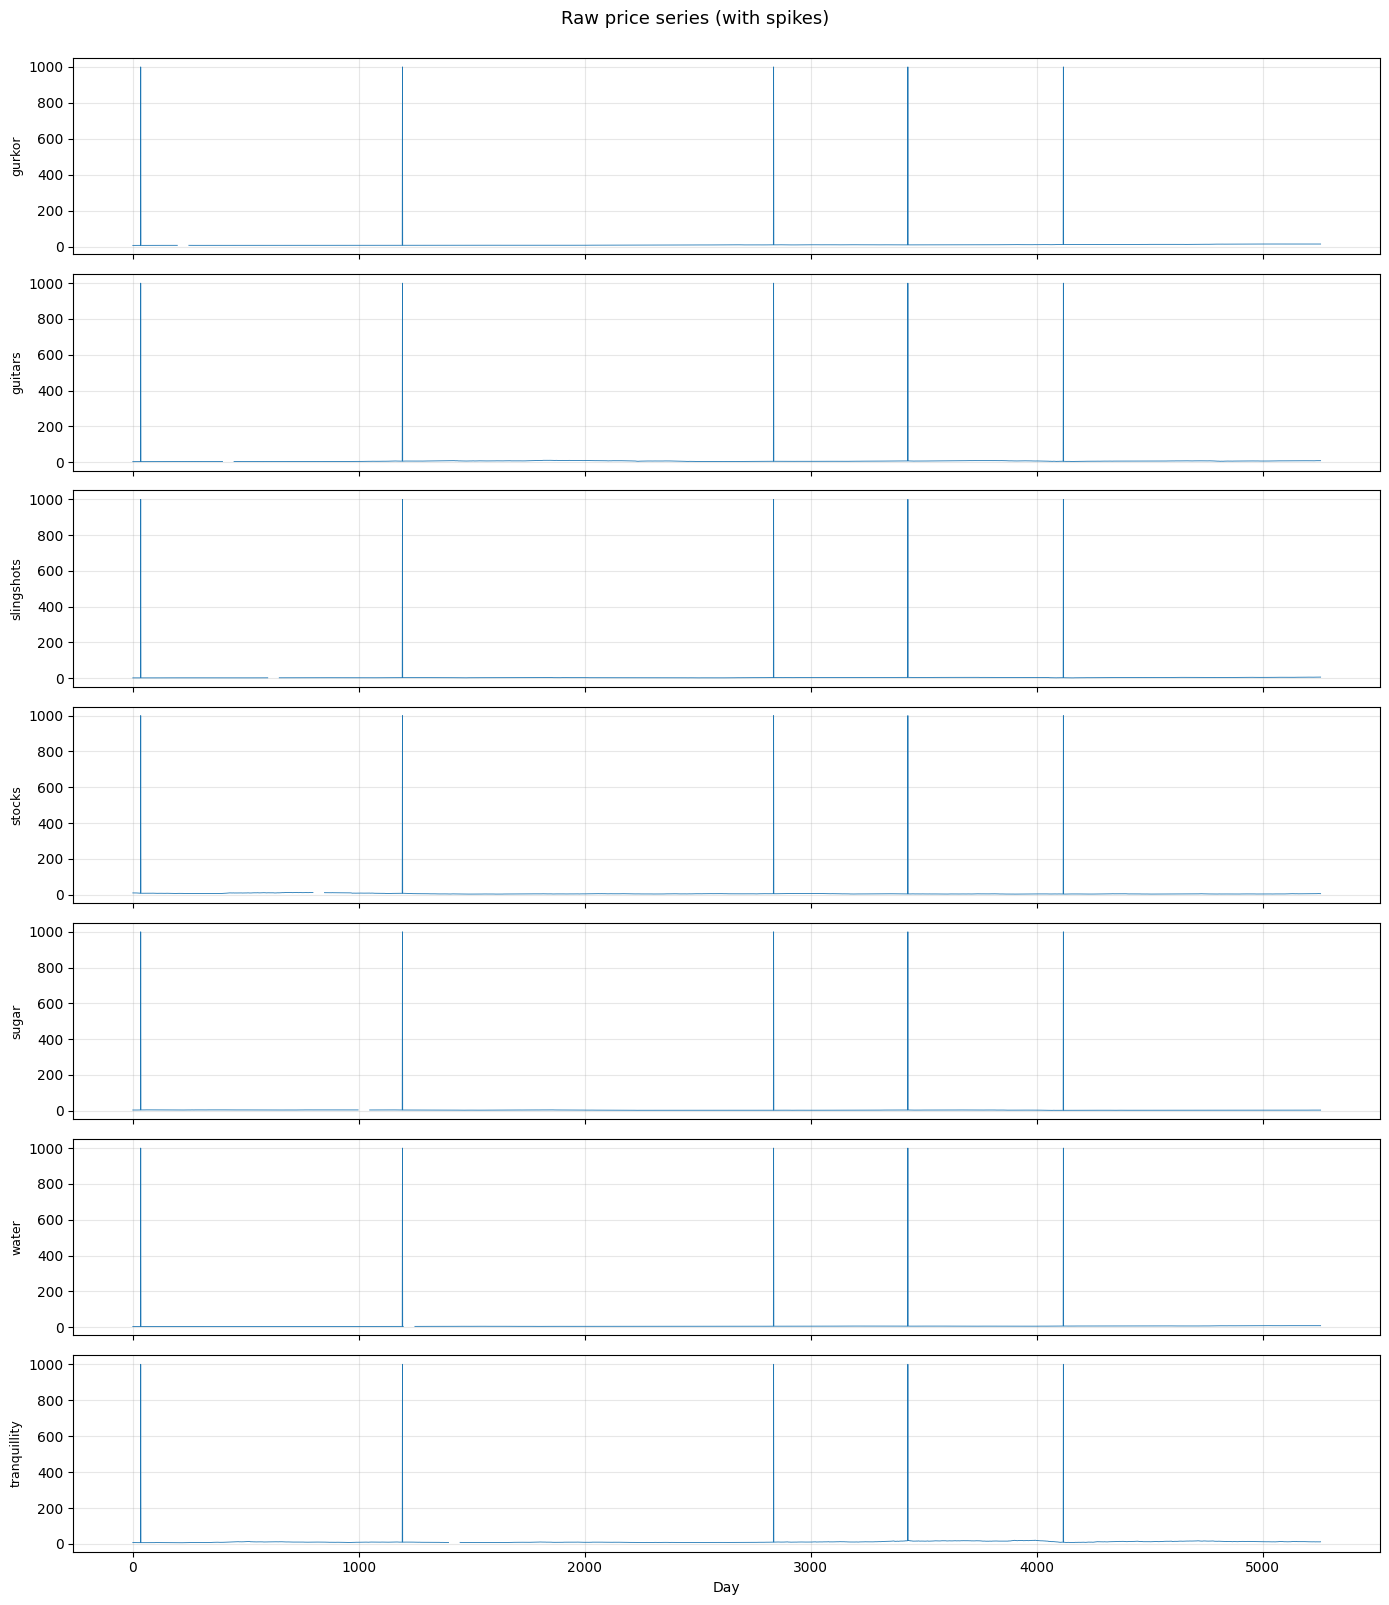

In [2]:
fig, axes = plt.subplots(7, 1, figsize=(14, 16), sharex=True)
for ax, col in zip(axes, cols):
    ax.plot(df['day'], df[col], linewidth=0.6)
    ax.set_ylabel(col, fontsize=9)
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel('Day')
fig.suptitle('Raw price series (with spikes)', fontsize=13, y=1.0)
plt.tight_layout()
plt.show()

## 3. Cleaning
Replace spikes (values = 1000) with NaN.

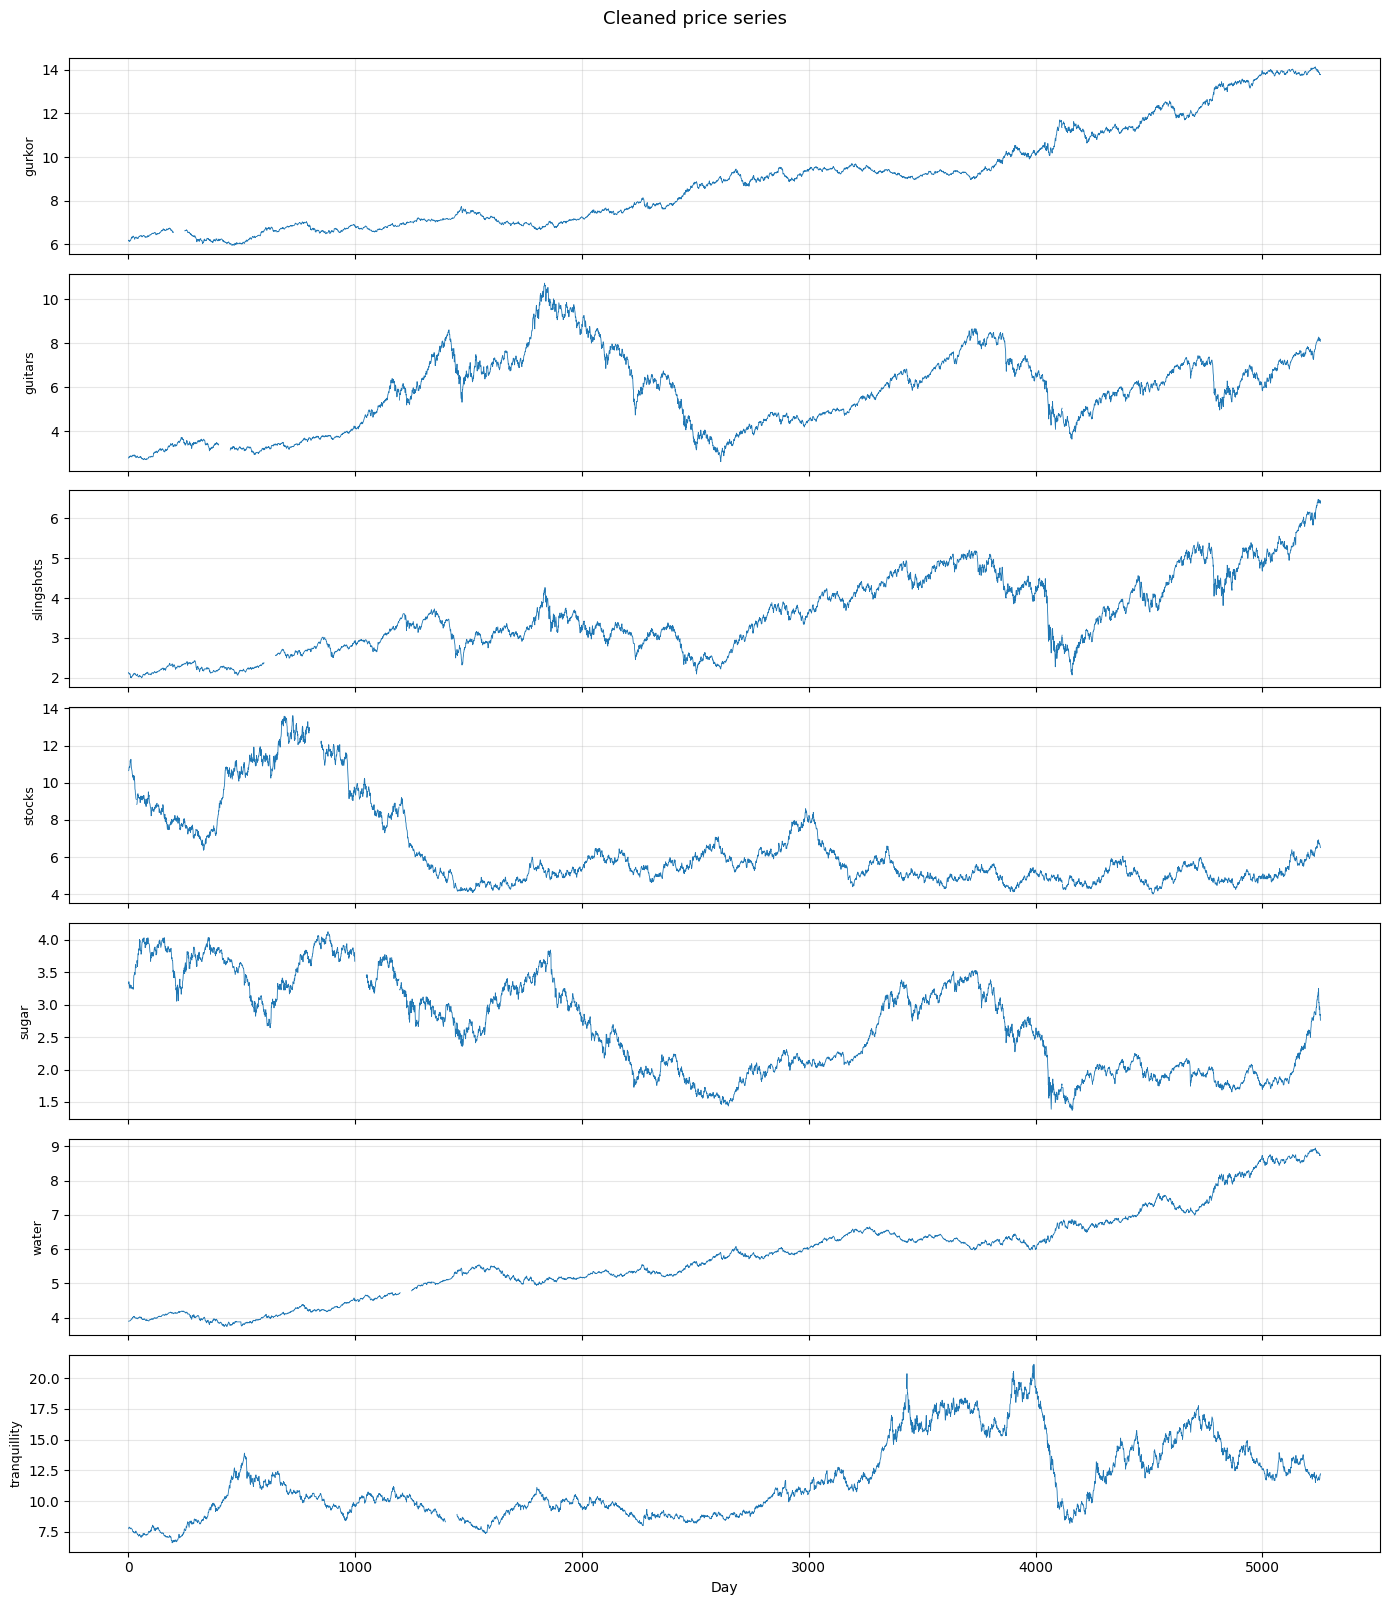

In [3]:
# Replace spikes
for col in cols:
    df.loc[df[col] == 1000, col] = np.nan

fig, axes = plt.subplots(7, 1, figsize=(14, 16), sharex=True)
for ax, col in zip(axes, cols):
    ax.plot(df['day'], df[col], linewidth=0.6)
    ax.set_ylabel(col, fontsize=9)
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel('Day')
fig.suptitle('Cleaned price series', fontsize=13, y=1.0)
plt.tight_layout()
plt.show()

### Observations on price levels
- **gurkor** and **water** are low-volatility, trending upward from ~4–6 to ~7–8 over 21 years.
- **guitars**, **slingshots**, **sugar**, **tranquillity** are high-volatility, with large swings.
- **stocks** trends downward from ~10 to ~2, unique among the series.
- Price levels are clearly non-stationary — we need returns.

## 4. Log-returns

$$r_t = \log(P_t / P_{t-1})$$

Log-returns are approximately stationary and better suited for statistical modelling.

In [4]:
log_ret = pd.DataFrame(index=df.index)
for col in cols:
    log_ret[col] = np.log(df[col]).diff()

log_ret[cols].describe().round(5)

,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
count,5194.00000,5194.00000,5194.00000,5194.00000,5194.00000,5194.00000,5194.00000
mean,0.00016,0.00024,0.00019,-0.00007,-0.00001,0.00015,0.00008
std,0.00394,0.01488,0.01475,0.01494,0.01521,0.00351,0.01259
min,-0.02484,-0.09306,-0.12190,-0.06047,-0.14124,-0.02613,-0.08669
25%,-0.00199,-0.00661,-0.00653,-0.00996,-0.00750,-0.00175,-0.00676
50%,0.00000,0.00054,0.00046,0.00016,0.00000,0.00009,0.00000
75%,0.00244,0.00748,0.00749,0.01031,0.00778,0.00219,0.00704
max,0.03628,0.12253,0.09250,0.05170,0.18916,0.01733,0.05977


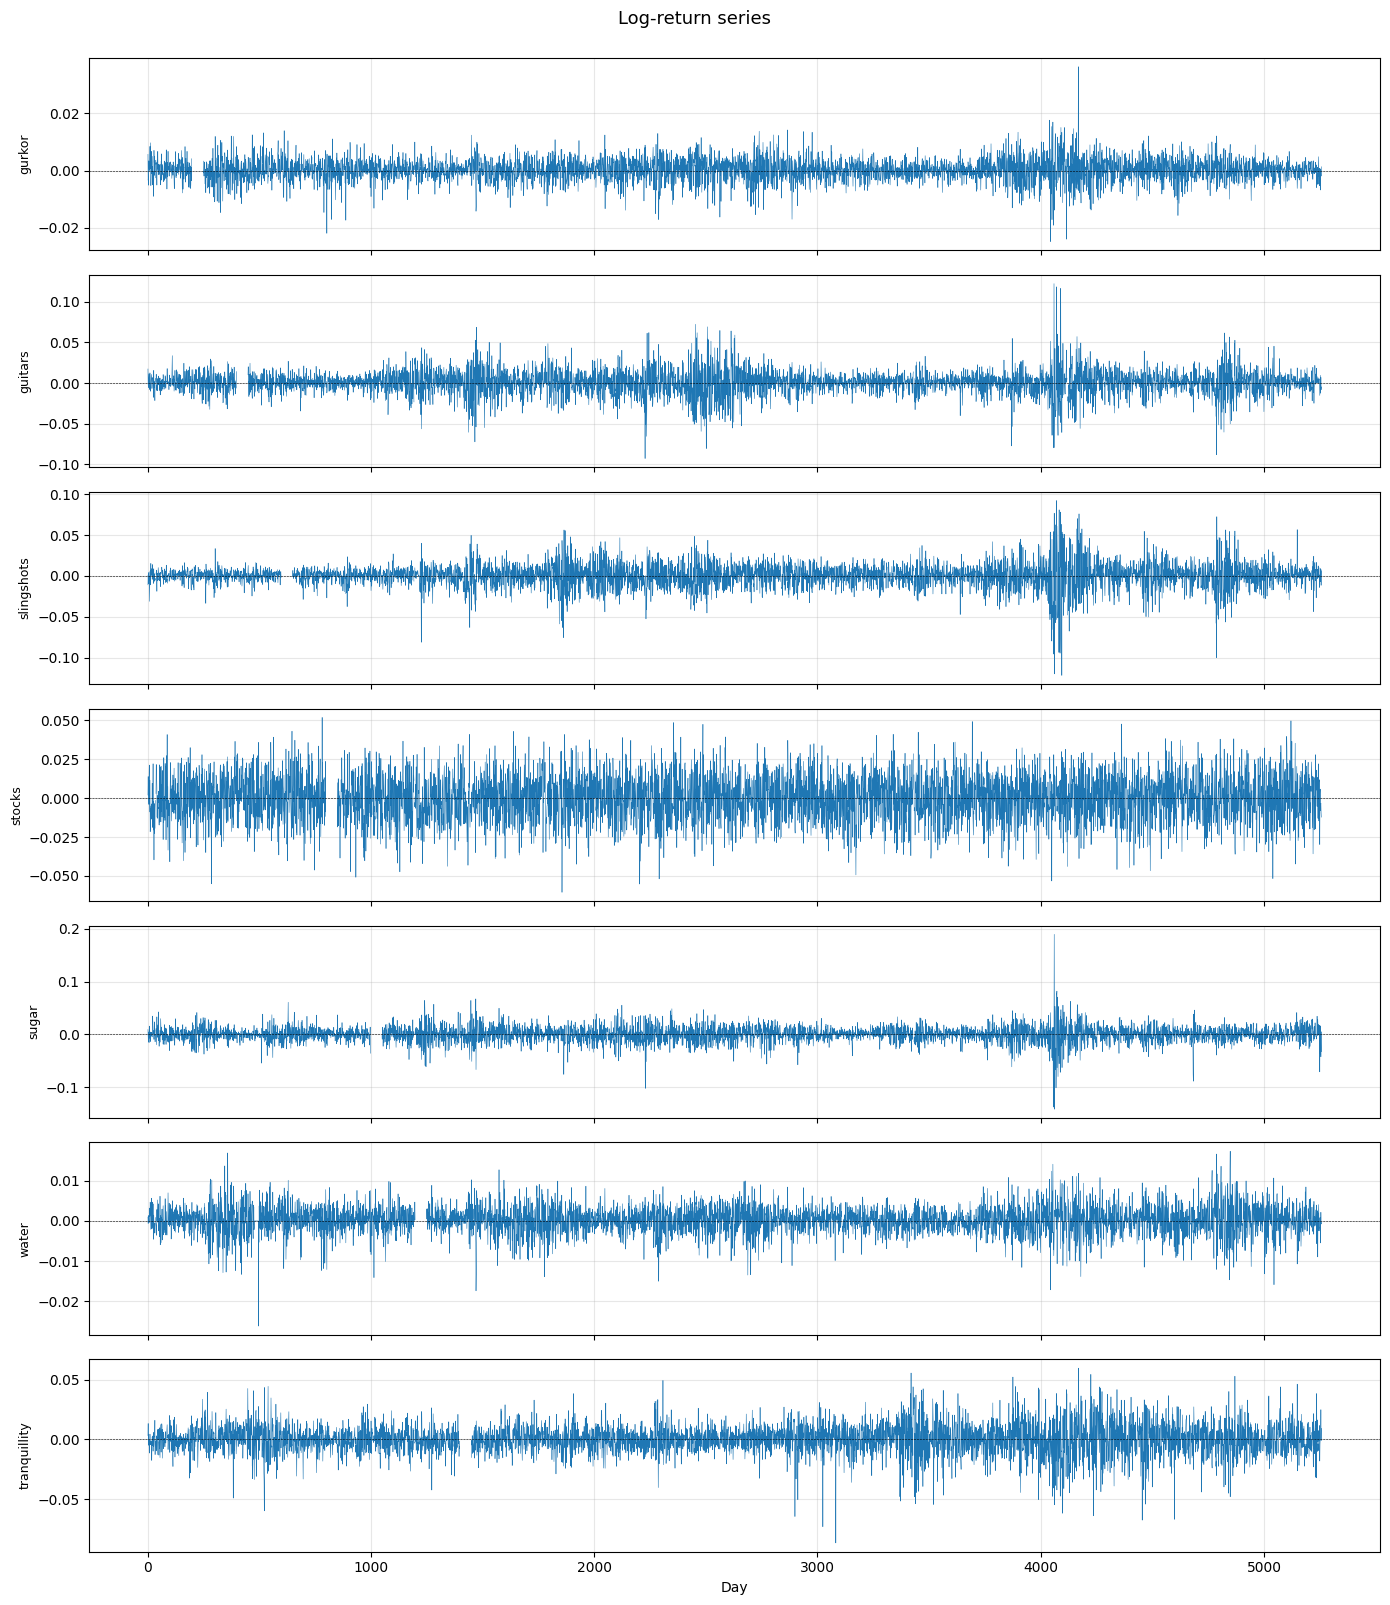

In [5]:
fig, axes = plt.subplots(7, 1, figsize=(14, 16), sharex=True)
for ax, col in zip(axes, cols):
    ax.plot(df['day'], log_ret[col], linewidth=0.4)
    ax.set_ylabel(col, fontsize=9)
    ax.axhline(0, color='black', linewidth=0.4, linestyle='--')
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel('Day')
fig.suptitle('Log-return series', fontsize=13, y=1.0)
plt.tight_layout()
plt.show()

### Key observations from returns
- **Volatility clustering** is clearly visible in all series except stocks — periods of calm alternate with bursts of large moves. This is a hallmark of ARCH/GARCH dynamics.
- **gurkor** and **water** are dramatically less volatile (daily σ ≈ 0.35–0.39%) than the rest (daily σ ≈ 1.3–1.5%).
- **stocks** has no volatility clustering and returns look much closer to iid — very different behaviour from all other series.
- Several series show fat tails (see kurtosis below).

## 5. Stationarity — ADF test
We test for unit roots. Price levels should be non-stationary; log-returns stationary.

In [6]:
print(f"{'Series':<15} {'Price p-val':>12} {'Return p-val':>13} {'Prices':>8} {'Returns':>9}")
print("-" * 60)
for col in cols:
    pp = adfuller(df[col].dropna())[1]
    pr = adfuller(log_ret[col].dropna())[1]
    print(f"{col:<15} {pp:>12.4f} {pr:>13.6f} {'nonstat':>8} {'stat':>9}")

Series           Price p-val  Return p-val   Prices   Returns
------------------------------------------------------------
gurkor                0.9905      0.000000  nonstat      stat
guitars               0.2646      0.000000  nonstat      stat
slingshots            0.7803      0.000000  nonstat      stat
stocks                0.1718      0.000000  nonstat      stat
sugar                 0.3219      0.000000  nonstat      stat
water                 0.9914      0.000000  nonstat      stat
tranquillity          0.1916      0.000000  nonstat      stat


All price series fail to reject the unit root (non-stationary). All log-return series reject it decisively (p ≈ 0) — confirming stationarity. **Work in log-return space for all modelling.**

## 6. Correlation structure

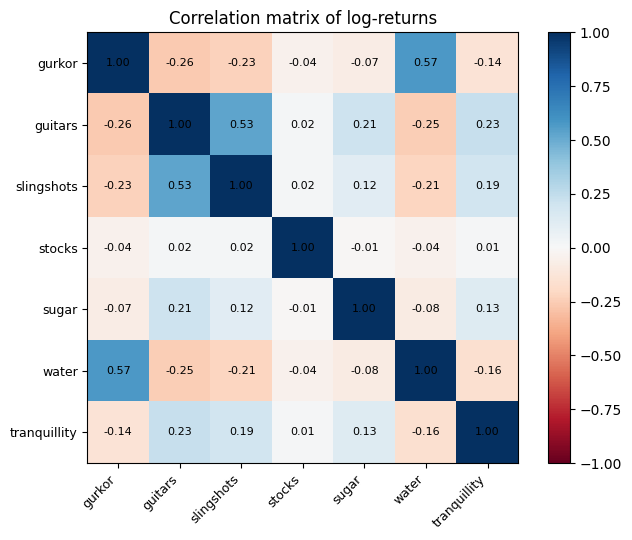

In [7]:
corr = log_ret[cols].dropna().corr()
fig, ax = plt.subplots(figsize=(7, 5.5))
im = ax.imshow(corr, cmap='RdBu', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(cols)))
ax.set_yticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(cols, fontsize=9)
for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)
ax.set_title('Correlation matrix of log-returns')
plt.tight_layout()
plt.show()

### Correlation groups

Three natural groups emerge:

| Group | Series | Within-group corr | Character |
|---|---|---|---|
| A (low-vol) | gurkor, water | +0.58 | Slow-moving, trending up, tight spreads |
| B (high-vol) | guitars, slingshots | +0.53 | Volatile, trending up, wide swings |
| C (independent) | stocks | ≈ 0 with all | Trending down, no clustering, iid-like |

**sugar** and **tranquillity** are loosely connected to Group B (corr 0.1–0.2) but not strongly enough to form a tight cluster.

Groups A and B are **negatively correlated** with each other (~−0.2 to −0.26) — when the low-vol pair rises, the high-vol pair tends to fall slightly.

This structure is directly useful for **Task 2** (interpolation): correlated series can inform each other's gaps.

## 6.1 Rolling cross-correlation (200-day window)

To see whether pairwise correlations are stable over time, we plot the 200-day rolling Pearson correlation of log-returns for every pair of series.

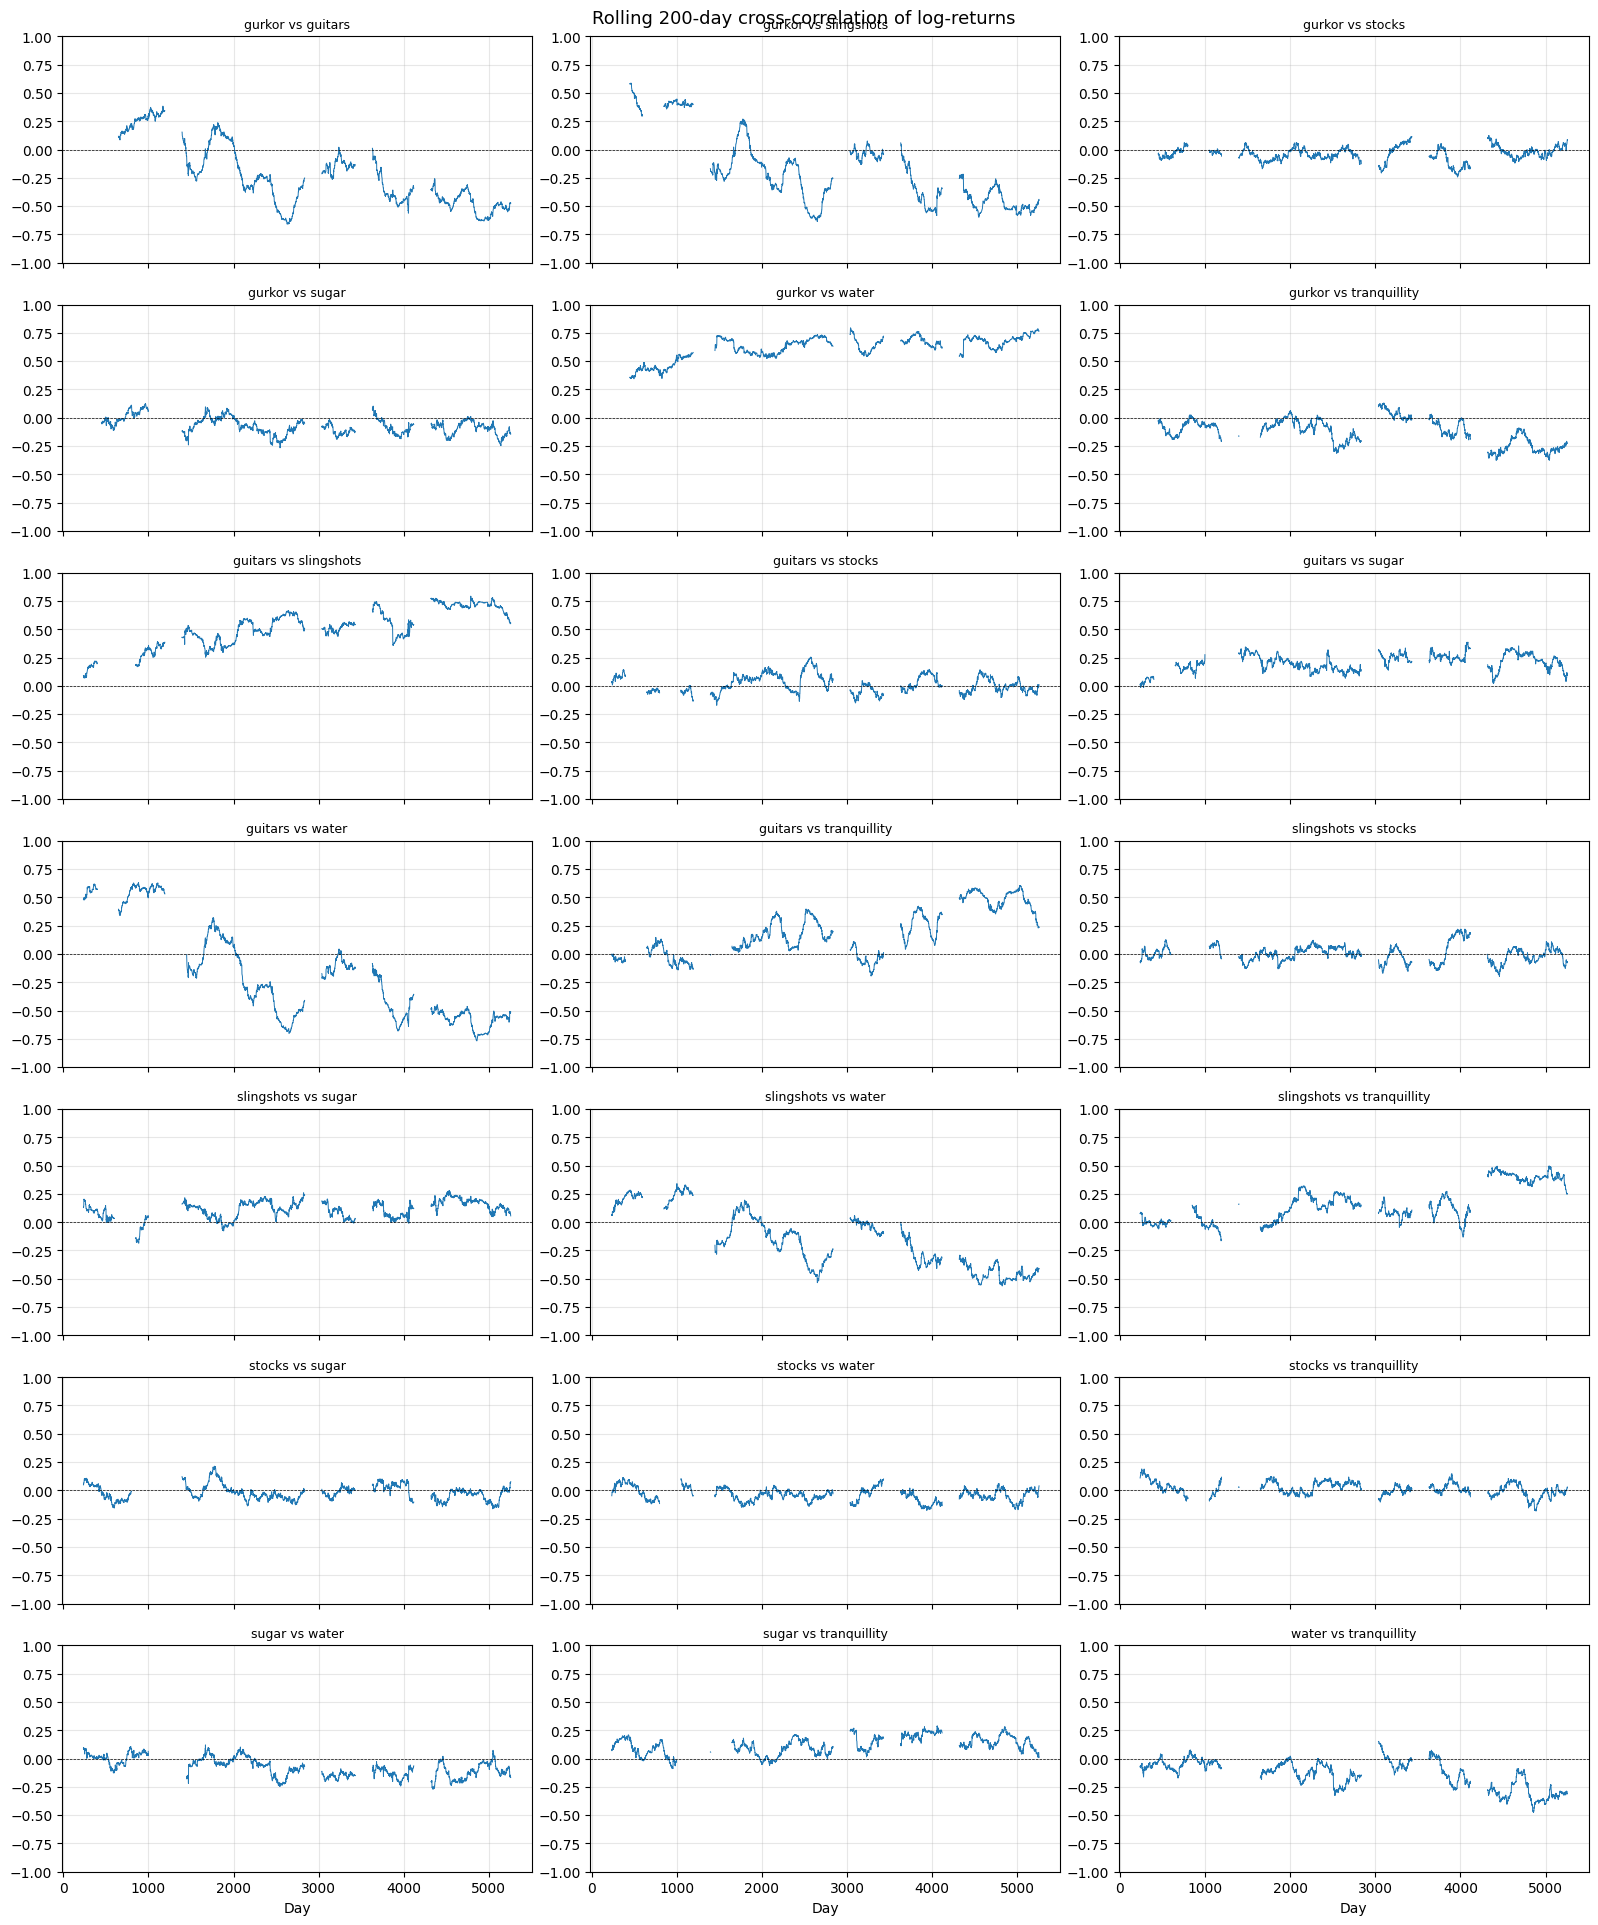

In [8]:
from itertools import combinations

window = 200
pairs = list(combinations(cols, 2))

n_cols = 3
n_rows = (len(pairs) + n_cols - 1) // n_cols  # 7 rows for 21 pairs

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 2.8), sharex=True)
axes = axes.flatten()

for ax, (a, b) in zip(axes, pairs):
    rolling_corr = log_ret[a].rolling(window).corr(log_ret[b])
    ax.plot(df['day'], rolling_corr, linewidth=0.7)
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
    ax.set_ylim(-1, 1)
    ax.set_title(f'{a} vs {b}', fontsize=9)
    ax.grid(True, alpha=0.3)

for ax in axes[len(pairs):]:
    ax.set_visible(False)

for ax in axes[(n_rows - 1) * n_cols : (n_rows - 1) * n_cols + n_cols]:
    ax.set_xlabel('Day')

fig.suptitle(f'Rolling {window}-day cross-correlation of log-returns', fontsize=13)
plt.tight_layout()
plt.show()

Time varying cross-correlations motivate the use of a shorter regression window in task 2.

## 7. Rolling volatility

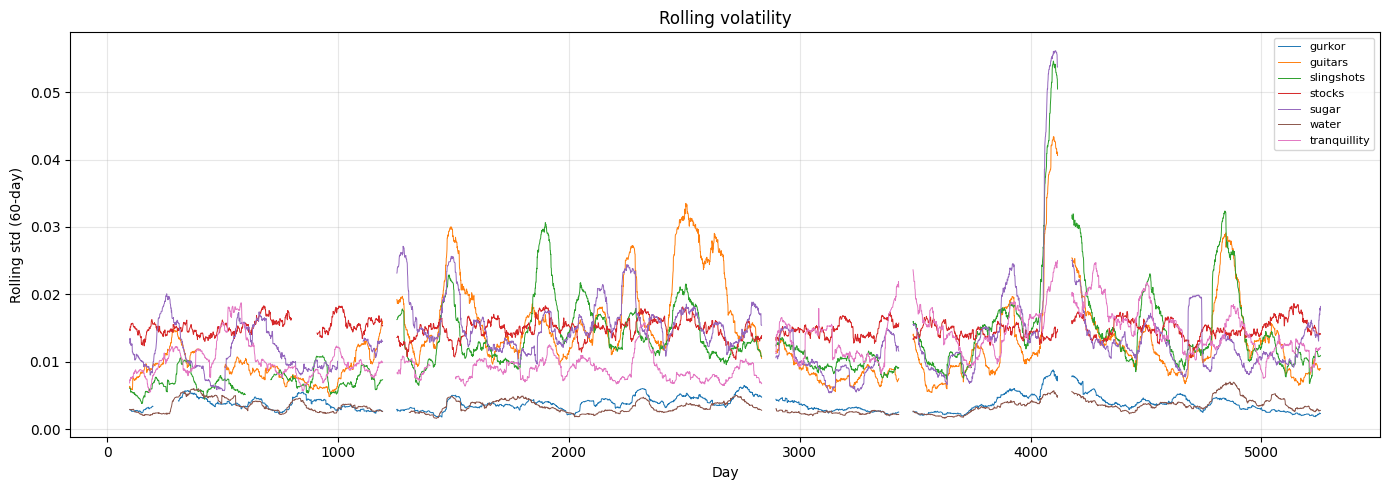

In [9]:
fig, ax = plt.subplots(figsize=(14, 5))
for col in cols:
    rolling_vol = log_ret[col].rolling(60).std()
    ax.plot(df['day'], rolling_vol, linewidth=0.7, label=col)
ax.set_xlabel('Day')
ax.set_ylabel('Rolling std (60-day)')
ax.set_title('Rolling volatility')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The two volatility regimes are unmistakable:
- gurkor and water hover around 0.2–0.5% daily vol throughout.
- The remaining series fluctuate between ~0.5% and ~2.5%, with clear clustering episodes.
- stocks has the most uniform volatility — consistent with its iid-like returns.

## 8. Autocorrelation — returns and squared returns

The ACF of returns checks for linear predictability. The ACF of squared returns (r²) checks for **ARCH effects** (volatility clustering).

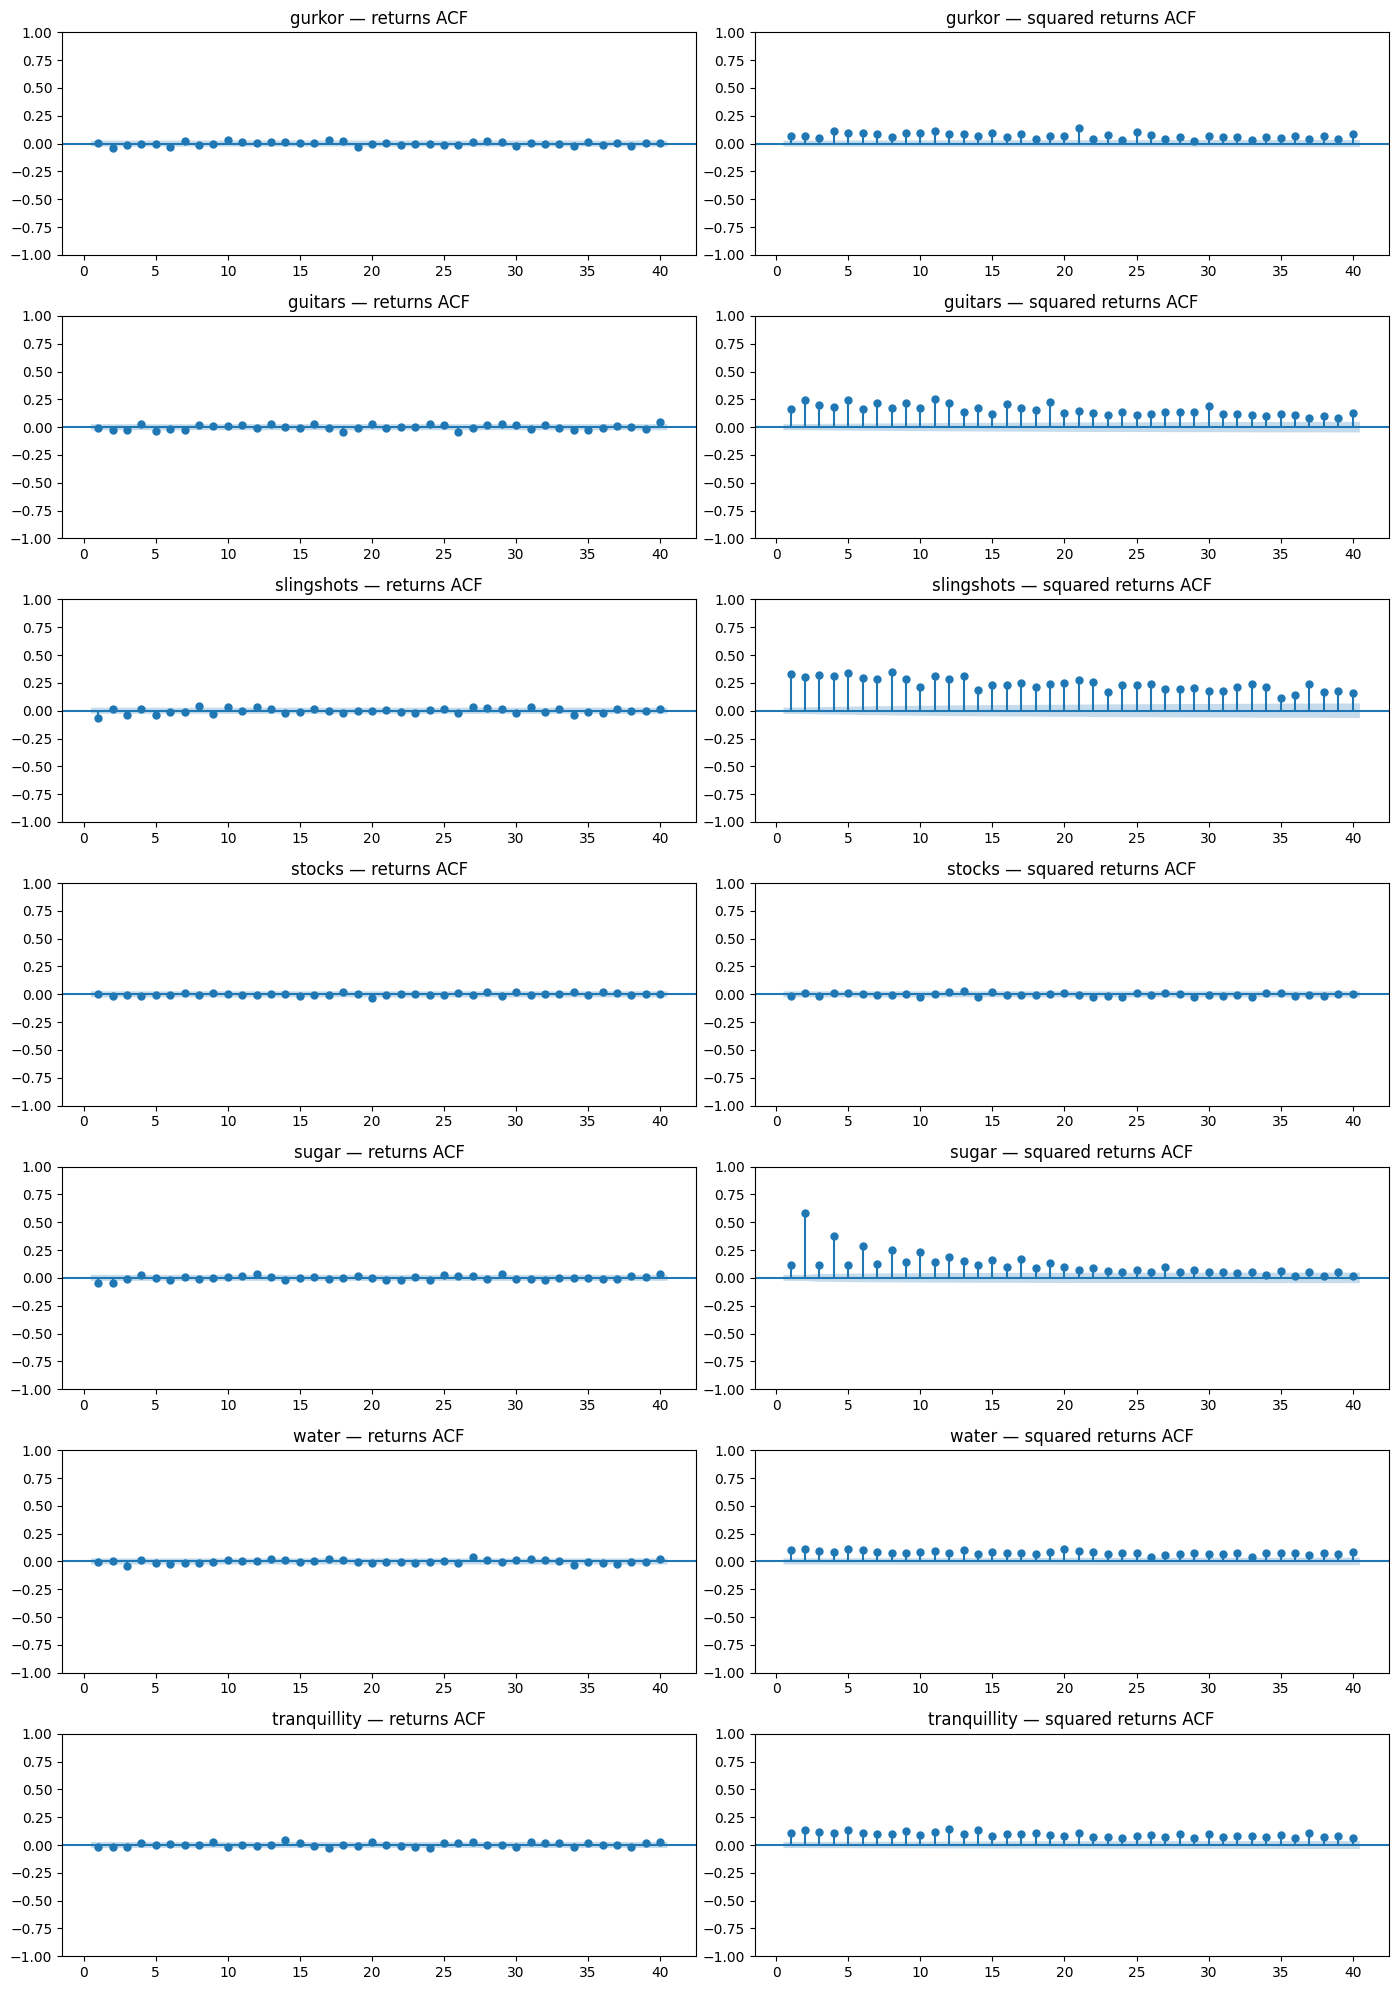

In [12]:
fig, axes = plt.subplots(len(cols), 2, figsize=(14, 20))
for i, col in enumerate(cols):
    r = log_ret[col].dropna()
    plot_acf(r,    ax=axes[i, 0], lags=40, title=f'{col} — returns ACF',         zero=False)
    plot_acf(r**2, ax=axes[i, 1], lags=40, title=f'{col} — squared returns ACF', zero=False)
plt.tight_layout()
plt.show()

### Ljung-Box test (lag 10)

In [13]:
print(f"{'Series':<15} {'Returns p':>10} {'Sq.Ret p':>10} {'ARCH?':>7}")
print("-" * 45)
for col in cols:
    r = log_ret[col].dropna()
    p_ret = acorr_ljungbox(r, lags=[10], return_df=True)['lb_pvalue'].values[0]
    p_sq  = acorr_ljungbox(r**2, lags=[10], return_df=True)['lb_pvalue'].values[0]
    arch = "YES" if p_sq < 0.05 else "NO"
    print(f"{col:<15} {p_ret:>10.4f} {p_sq:>10.6f} {arch:>7}")

Series           Returns p   Sq.Ret p   ARCH?
---------------------------------------------
gurkor              0.0069   0.000000     YES
guitars             0.0058   0.000000     YES
slingshots          0.0000   0.000000     YES
stocks              0.9345   0.710547      NO
sugar               0.0003   0.000000     YES
water               0.1159   0.000000     YES
tranquillity        0.2916   0.000000     YES


**Returns ACF:** Most series show weak but statistically significant autocorrelation — slight linear predictability exists. stocks shows none (truly iid-like).

**Squared returns ACF:** All series except stocks have highly significant ARCH effects. This confirms volatility clustering and means **GARCH-type models** are appropriate for Tasks 3 and 4. stocks is the exception — its squared returns show no serial dependence at all.

## 9. Return distributions and fat tails

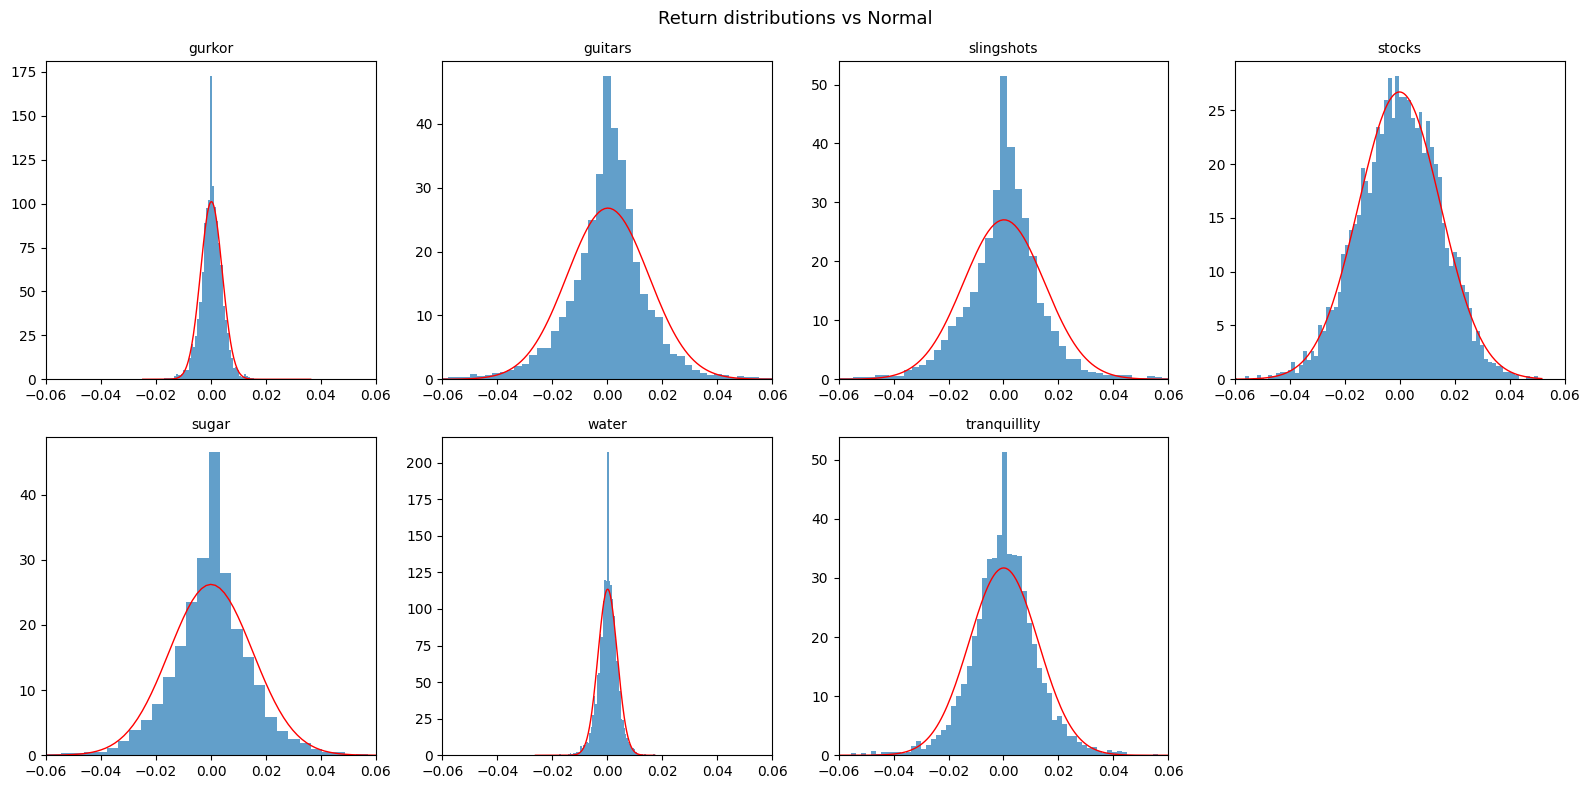

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(cols):
    r = log_ret[col].dropna()
    axes[i].hist(r, bins=80, density=True, alpha=0.7, edgecolor='none')
    x = np.linspace(r.min(), r.max(), 200)
    axes[i].plot(x, norm.pdf(x, r.mean(), r.std()), 'r-', linewidth=1)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlim(-0.06, 0.06)
axes[-1].set_visible(False)
fig.suptitle('Return distributions vs Normal', fontsize=13)
plt.tight_layout()
plt.show()

In [15]:
print("Excess kurtosis:")
for col in cols:
    k = log_ret[col].kurtosis()
    print(f"  {col}: {k:.2f}")

Excess kurtosis:
  gurkor: 3.52
  guitars: 5.56
  slingshots: 6.44
  stocks: 0.08
  sugar: 10.70
  water: 2.25
  tranquillity: 2.98


All series have positive excess kurtosis (fat tails). Extreme moves happen more often than a normal distribution predicts. sugar is the most extreme (κ = 10.7). stocks is nearly Gaussian (κ ≈ 0), further confirming its unique iid behaviour. Fat tails further motivate the use of an ARCH/GARCH model.

## 10. Summary

| Series | Mean return | Daily vol | Ann. vol | Kurtosis | ARCH | Correlation group |
|---|---|---|---|---|---|---|
| gurkor | +0.016% | 0.39% | 6.3% | 3.5 | YES | A (low-vol), +0.58 with water |
| guitars | +0.024% | 1.49% | 23.6% | 5.6 | YES | B (high-vol), +0.53 with slingshots |
| slingshots | +0.019% | 1.47% | 23.4% | 6.4 | YES | B (high-vol), +0.53 with guitars |
| stocks | −0.007% | 1.49% | 23.7% | 0.1 | NO | C (independent) |
| sugar | −0.001% | 1.52% | 24.1% | 10.7 | YES | Loosely B |
| water | +0.015% | 0.35% | 5.6% | 2.3 | YES | A (low-vol), +0.58 with gurkor |
| tranquillity | +0.008% | 1.26% | 20.0% | 3.0 | YES | Loosely B |

### Key takeaways for subsequent tasks

**Task 2 (Interpolation):** The strong within-group correlations (A: gurkor↔water, B: guitars↔slingshots) mean correlated series can inform gap-filling. The gaps are staggered in time, so when one series has a gap, its correlated partner has data. Linear interpolation is a simple baseline; multivariate methods (e.g., regression on the correlated partner) should improve on it.

**Task 3 (Extrapolation):** Log-returns are stationary, so the best simple forecast of the next return is the mean (~0). For price levels, this means a random walk — the forecast is just the last observed price, with uncertainty growing as √t. ARIMA(0,1,0) is the minimal model. GARCH can improve confidence intervals by capturing time-varying volatility. stocks can be modelled as a simple random walk with drift.

**Task 4 (Strategies):** The near-zero mean returns for sugar and stocks, combined with negative drift for stocks, make buy-and-hold risky there. Volatility clustering (ARCH effects) suggests momentum/mean-reversion strategies may work. The low-vol pair (gurkor, water) has positive drift and low risk — attractive for buy-and-hold. The negative cross-correlation between groups A and B opens the door for long/short portfolio strategies.